In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
pd.set_option('display.max_columns', None)

In [2]:
url = "https://minio.lab.sspcloud.fr/projet-funathon/2026/project1/data/1_input/transactions_EN.parquet"

data = pd.read_parquet(url)

In [3]:
data.shape

(9999635, 43)

In [4]:
data.head()

,trans_date,trans_year,trans_month,price,prop_type,prop_year_harm,prop_loc_dep,prop_loc_citycode,prop_loc_x,prop_loc_y,dist_tosea,n_floors,n_bath,n_show,n_sink,n_wc,n_mrooms,n_eatr,n_slr,n_kit8,n_kit9,n_washr,n_ancrooms,n_rooms,farea,has_water,has_elec,stair,has_gas,has_elevator,has_cheating,has_rchute,has_mdrainage,nth_floor,s_land_artif,s_land_agri,s_land_nat,n_garage,n_pool,n_terrace,n_attic,n_basmt,n_otherannex
0,2017-04-25,2017,4,144066.438486,1,2014,60,60370,2.106281,49.258202,10000.0,2,2,0,2,2,9,2,4,1,0,2,2,11,119,2,2,1,2,1,2,1,0,0,802,0,0,1,0,0,0,0,0
1,2012-08-12,2012,8,158839.793280,1,1987,60,60003,2.173426,49.520604,10000.0,1,1,1,1,1,6,1,3,0,1,1,2,8,119,2,2,1,0,1,2,1,2,0,859,0,0,1,0,0,0,0,0
2,2012-09-13,2012,9,70960.301727,1,2006,60,60592,1.735172,49.415124,10000.0,2,1,0,1,1,9,2,4,0,1,2,0,9,111,2,2,1,0,1,2,1,0,0,765,0,0,1,0,0,0,0,0
3,2013-02-26,2013,2,43676.516263,1,1992,60,60057,2.083790,49.420146,10000.0,2,0,1,2,1,9,1,5,0,1,2,2,11,115,2,2,1,1,1,2,1,2,0,769,0,0,1,0,0,0,0,0
4,2017-03-05,2017,3,194822.649580,1,1971,60,60513,2.382319,49.208644,10000.0,2,1,1,2,2,8,1,4,1,0,2,4,12,112,2,2,1,0,1,2,1,0,0,880,0,0,1,0,0,0,0,0


In [5]:
data.isna().mean()[data.isna().mean()>0]

prop_loc_citycode    0.001302
prop_loc_x           0.001302
prop_loc_y           0.001302
dist_tosea           0.001302
dtype: float64

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.trans_date = pd.to_datetime(data.trans_date)

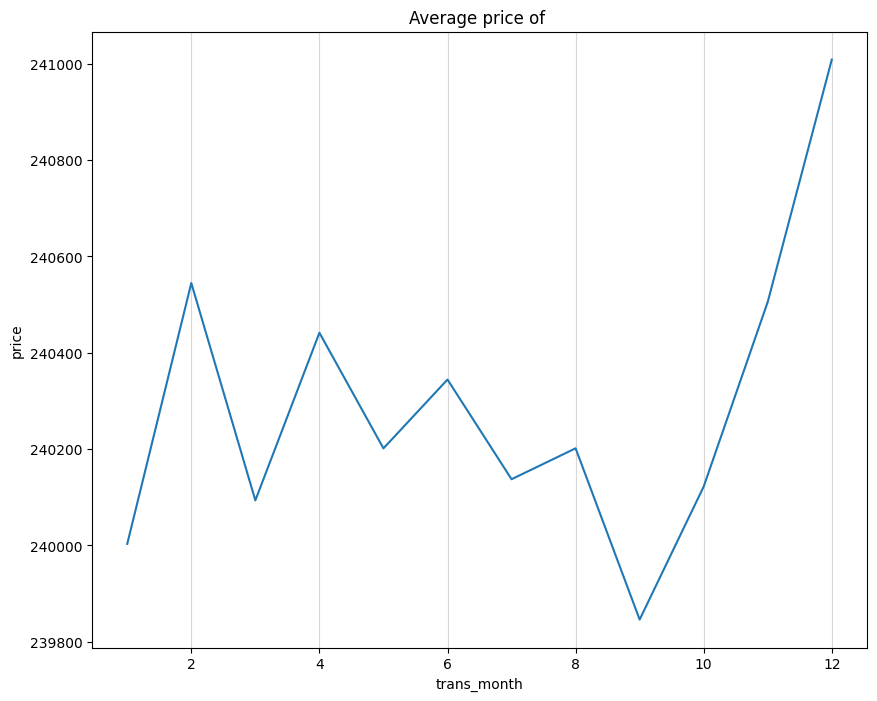

In [8]:
plt.figure(figsize=(10, 8))
plt.title("Average price of ")

sns.lineplot(data=data.groupby("trans_month")["price"].mean().reset_index(), x="trans_month", y="price")
plt.grid(True, axis="x", alpha=.5)

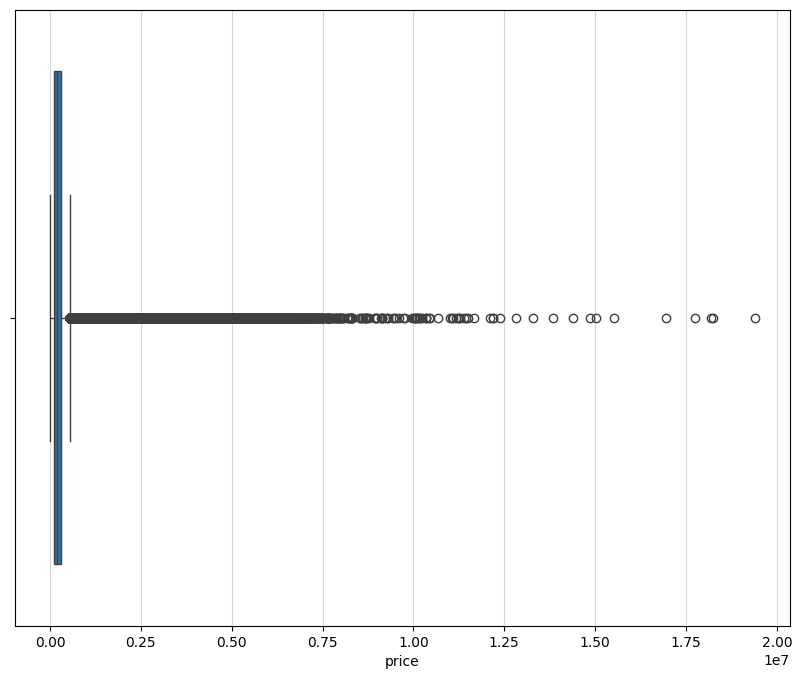

In [9]:
plt.figure(figsize=(10, 8))
sns.boxplot(data=data, x="price")
plt.grid(True, axis="x", alpha=.5)

In [10]:
data["log_price"] = data.price.transform(np.log1p)

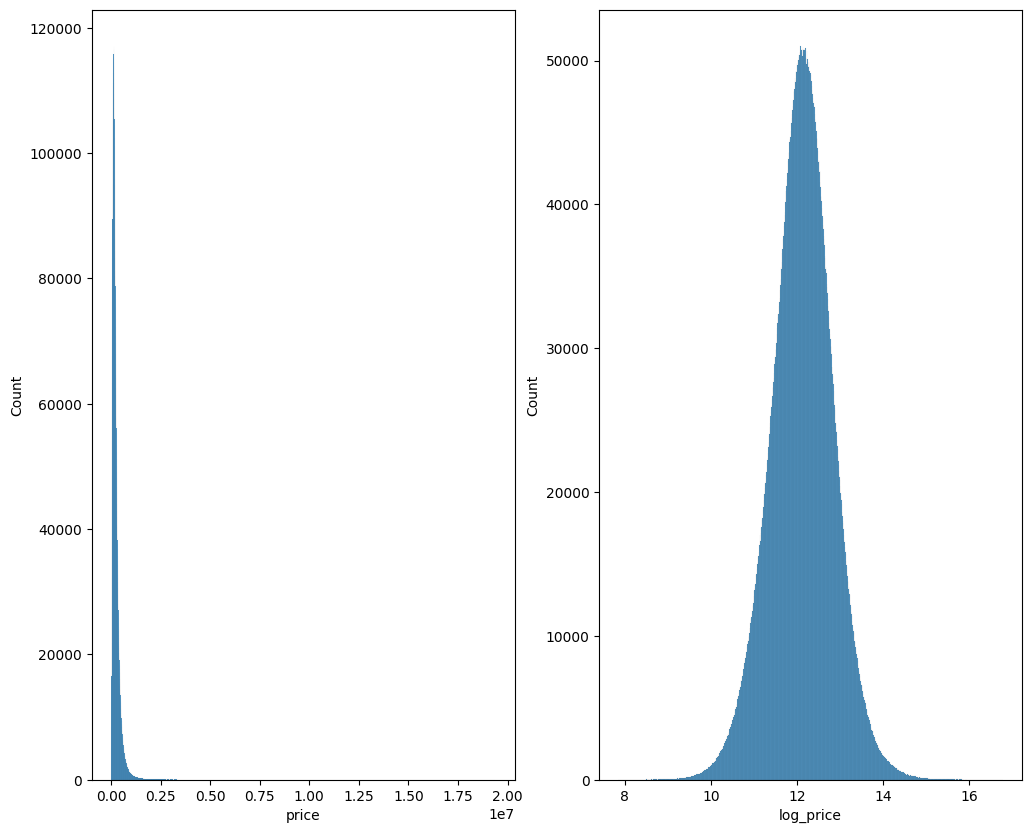

<Figure size 1000x600 with 0 Axes>

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 10))
plt.figure(figsize=(10, 6))
for i, col in enumerate(["price", "log_price"]):
    sns.histplot(data=data, x=col, ax=ax[i])
    

In [12]:
data["nan_flag"] = data.isnull().any(axis=1).astype(int)

<Axes: >

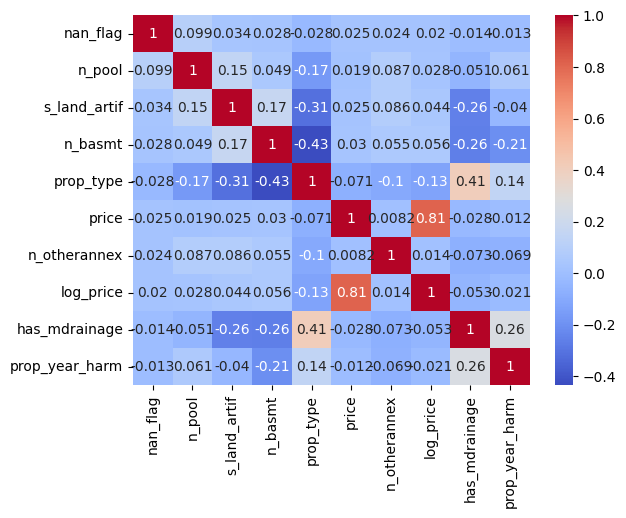

In [17]:
corr = data.select_dtypes(include="number").corr().apply(np.abs)

corr_nan = corr["nan_flag"].sort_values(ascending=False)

top_cols = corr_nan.abs().sort_values(ascending=False).head(10).index

sns.heatmap(
    data=data[top_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

In [ ]:
corr = data.select_dtypes(include="number").corr("spearman").apply(np.abs)

corr_nan = corr["price"].sort_values(ascending=False)

top_cols = corr_nan.abs().sort_values(ascending=False).head(10).index

sns.heatmap(
    data=data[top_cols].corr(),
    annot=True,
    cmap="coolwarm"
)